<a href="https://colab.research.google.com/github/JaswanthJavangula/ML_Practise/blob/main/1ML%20JAshu/Decision%20Tree%20-%20Reg%26Class/diabetes_prediction_using_Decision_Tree_regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
data = load_diabetes()
print(data["DESCR"])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [21]:
df= pd.DataFrame(load_diabetes().data,columns=load_diabetes().feature_names)
df["Target"] = load_diabetes().target
df.head(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0


In [22]:
X = df.drop("Target",axis=1)
y= df['Target']

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=10)

<Axes: >

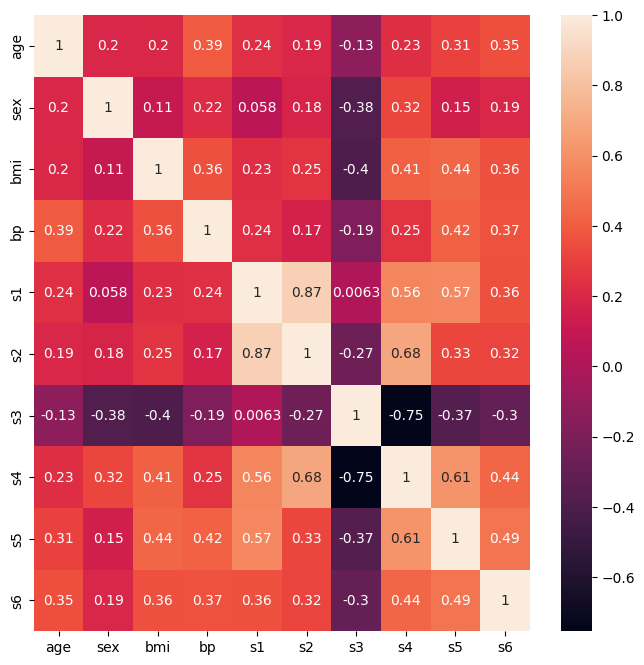

In [29]:
corr_X_train = X_train.corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr_X_train,annot=True)

In [30]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(X_train,y_train)

DecisionTreeRegressor()

hyperparameter tuning


In [31]:
param_grid ={
    "criterion": ["squared_error", "absolute_error", "poisson"],
    "splitter" : ["best", "random"],
    "max_depth" : [1,2,3,4,5,10,15,20,25,None],
    "max_features" : ["auto", "sqrt","log2"]
}


In [33]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=dtr,param_grid=param_grid,cv=5,scoring ='neg_mean_squared_error')
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25, None],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [34]:
grid_search.best_params_

{'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': 'log2',
 'splitter': 'best'}

In [35]:
y_pred1 = grid_search.predict(X_test)

In [36]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print(f"MSE: {mean_squared_error(y_test,y_pred1)}")
print(f"MAE: {mean_absolute_error(y_test,y_pred1)}")
print(f"R2: {r2_score(y_test,y_pred1)}")

MSE: 4903.25926629021
MAE: 56.74675384089197
R2: 0.2251083862211496


[Text(0.6750734661697247, 0.975, 'x[8] <= 0.022\nsquared_error = 5757.456\nsamples = 309\nvalue = 152.738'),
 Text(0.47717173165137616, 0.925, 'x[2] <= 0.005\nsquared_error = 4016.257\nsamples = 205\nvalue = 123.444'),
 Text(0.5761225989105505, 0.95, 'True  '),
 Text(0.37774751529051986, 0.875, 'x[7] <= 0.031\nsquared_error = 2592.764\nsamples = 148\nvalue = 107.615'),
 Text(0.30327790519877673, 0.825, 'x[0] <= 0.022\nsquared_error = 2220.402\nsamples = 127\nvalue = 101.008'),
 Text(0.23881880733944955, 0.775, 'x[3] <= 0.115\nsquared_error = 2062.541\nsamples = 98\nvalue = 93.898'),
 Text(0.2357607033639144, 0.725, 'x[8] <= -0.009\nsquared_error = 1928.519\nsamples = 97\nvalue = 92.639'),
 Text(0.1982033639143731, 0.675, 'x[2] <= 0.003\nsquared_error = 1459.603\nsamples = 78\nvalue = 87.577'),
 Text(0.1951452599388379, 0.625, 'x[3] <= -0.001\nsquared_error = 1312.285\nsamples = 77\nvalue = 86.117'),
 Text(0.16093272171253822, 0.575, 'x[3] <= -0.007\nsquared_error = 1289.903\nsamples = 

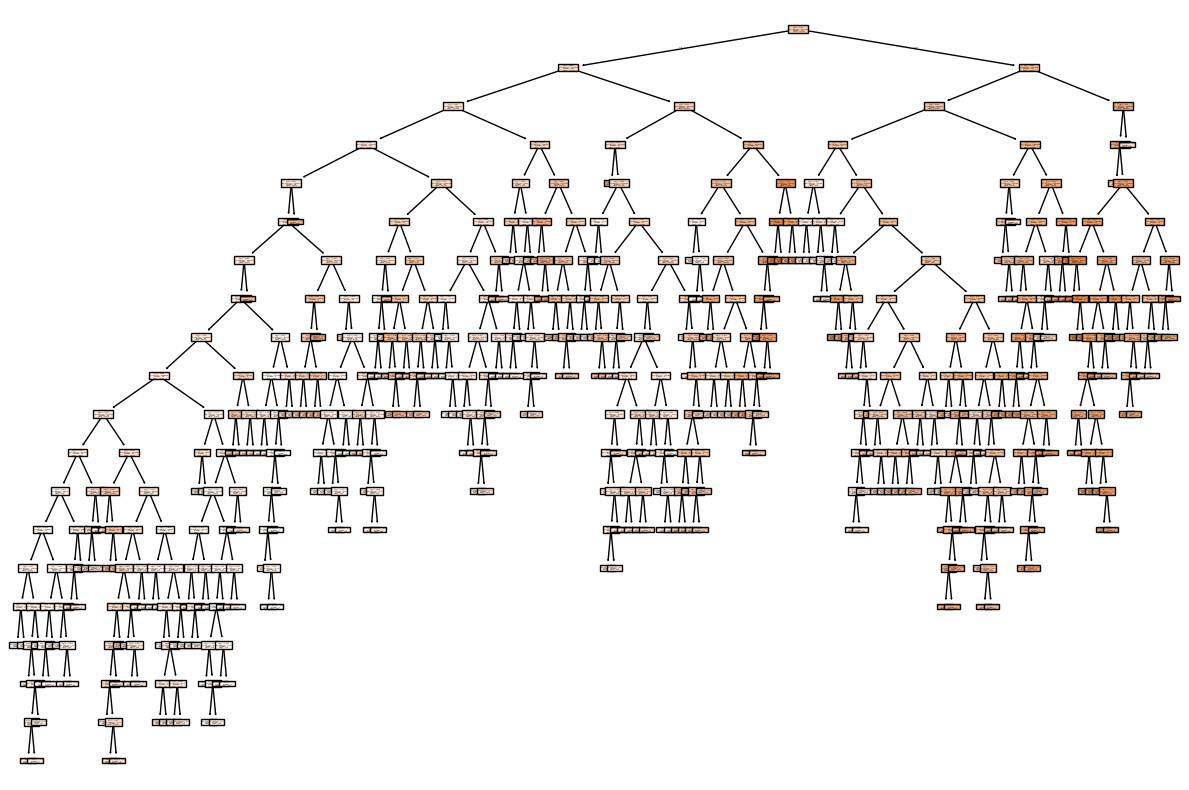

In [42]:
from sklearn import tree
plt.figure(figsize = (15,10))
tree.plot_tree(dtr,filled=True)

In [52]:
sample_model = DecisionTreeRegressor(
    criterion="poisson",
    max_features ="log2",
    splitter ="best",
    max_depth =4
    )
sample_model.fit(X_train,y_train)

DecisionTreeRegressor(criterion='poisson', max_depth=4, max_features='log2')

[Text(0.5, 0.9, 'x[2] <= 0.005\npoisson = 18.919\nsamples = 309\nvalue = 152.738'),
 Text(0.25, 0.7, 'x[3] <= 0.039\npoisson = 13.883\nsamples = 184\nvalue = 121.516'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[8] <= -0.004\npoisson = 12.256\nsamples = 156\nvalue = 114.359'),
 Text(0.0625, 0.3, 'x[0] <= 0.029\npoisson = 9.434\nsamples = 103\nvalue = 97.553'),
 Text(0.03125, 0.1, 'poisson = 8.518\nsamples = 87\nvalue = 91.011'),
 Text(0.09375, 0.1, 'poisson = 7.378\nsamples = 16\nvalue = 133.125'),
 Text(0.1875, 0.3, 'x[7] <= 0.031\npoisson = 10.94\nsamples = 53\nvalue = 147.019'),
 Text(0.15625, 0.1, 'poisson = 9.895\nsamples = 28\nvalue = 124.679'),
 Text(0.21875, 0.1, 'poisson = 8.087\nsamples = 25\nvalue = 172.04'),
 Text(0.375, 0.5, 'x[9] <= 0.018\npoisson = 15.826\nsamples = 28\nvalue = 161.393'),
 Text(0.3125, 0.3, 'x[3] <= 0.046\npoisson = 16.47\nsamples = 14\nvalue = 137.857'),
 Text(0.28125, 0.1, 'poisson = 0.0\nsamples = 1\nvalue = 50.0'),
 Text(0.34375, 0.1, 'poisson

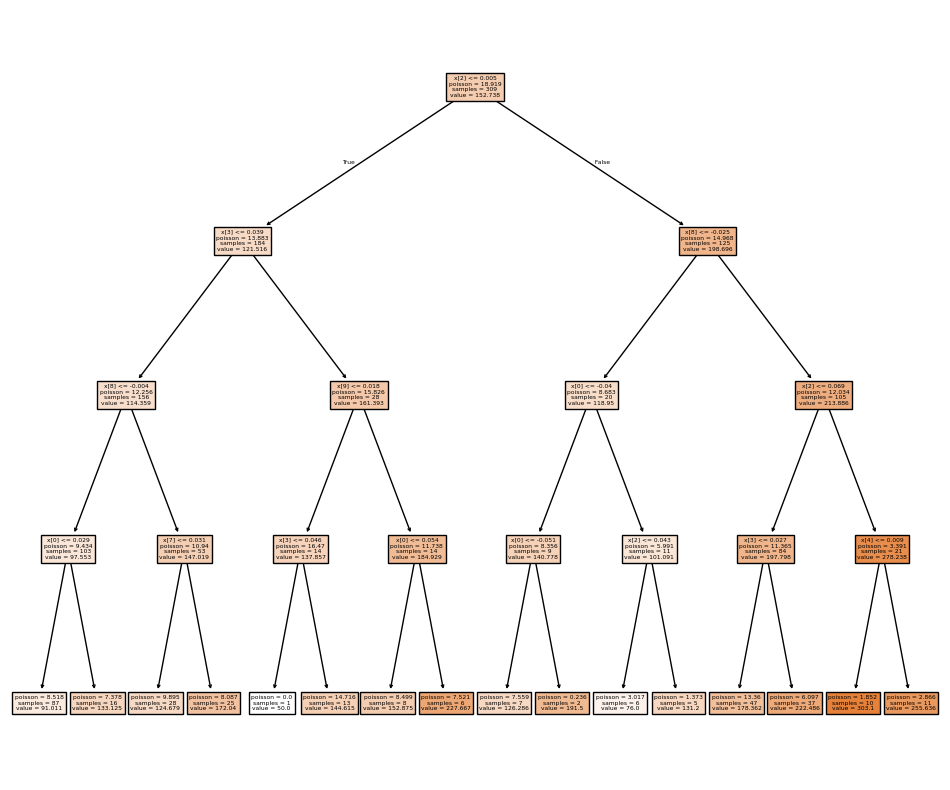

In [53]:
plt.figure(figsize= (12,10))
tree.plot_tree(sample_model,filled=True)